### 1. Importação de bibliotecas e configuração do ambiente

* Objetivo  

 Preparar o ambiente de desenvolvimento, importar as bibliotecas necessárias e configurar opções de visualização de dados 

In [1]:
# Importação organizada em blocos
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/gustavo/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gustavo/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/home/gustavo/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/gustavo/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/h

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/gustavo/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/gustavo/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/home/gustavo/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/gustavo/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/h

AttributeError: _ARRAY_API not found

In [2]:
import numpy as np

In [3]:
## Visualização 
import matplotlib.pyplot as plt 

In [4]:
## Utilidades
from pathlib import Path 
from datetime import datetime 
import unicodedata as ud

In [5]:
## Configurações globais 
pd.options.display.max_columns = 100 
pd.options.display.width = 150 

### 2. Estruturação das pastas do Projeto 

#### Objetivo 

Organizar os arquivos do projeto em diretórios específicos, separando dados brutos, dados tratados, relatórios e demais artefatos produzidos durante o trabalho

In [6]:
RAIZ = Path(".")

In [7]:
PASTAS = [
    
    "dados_brutos", 
    "dados_tratados", 
    "notebooks", 
    "sql", 
    "dashboards", 
    "relatorios", 
    "apresentacao", 
    "logs"
]

In [8]:
for pasta in PASTAS: 
    
    (RAIZ / pasta).mkdir(parents=True, exist_ok = True)

In [9]:
print("Estrutura de diretórios criada / verificada: ")
for pasta in PASTAS:
    print(f"{pasta}")

Estrutura de diretórios criada / verificada: 
dados_brutos
dados_tratados
notebooks
sql
dashboards
relatorios
apresentacao
logs


### 3. Parâmetros do Projeto 

#### Objetivo 

Centralizar os caminhos dos arquivos utilizados no projeto, facilitando futuras alterações sem modificar diversas partes do código

In [10]:
ARQUIVO_BRUTO = Path("dados_brutos/acidentes2025.csv")

In [11]:
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")

In [12]:
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")

In [13]:
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")

In [14]:
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")

In [15]:
ARQUIVO_README = Path("README.md")

In [16]:
SEPARADOR = ";"

In [17]:
ENCODING_ENTRADA = "latin1"

In [18]:
ENCODING_SAIDA = "utf-8-sig"

In [19]:
print("Parâmetros carregados")

Parâmetros carregados


### 4. Carregamento da Base de Dados

#### Objetivo 

Realizar a leitura do arquivo CSV contendo os registros de acidentes da PRF, garantindo compatibilidade com diferentes codificações de texto

In [20]:
## Carregamento do arquivo bruto 

try: 
    
    df_bruto = pd.read_csv(ARQUIVO_BRUTO, sep=SEPARADOR, encoding="utf-8")
    
except UnicodeDecodeError: 
    
    df_bruto = pd.read_csv(ARQUIVO_BRUTO, sep=SEPARADOR, encoding="latin1")
    
print("Base bruta carregada com sucesso") 
print("Dimensão: ", df_bruto.shape) 
df_bruto.head()

Base bruta carregada com sucesso
Dimensão:  (72529, 30)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [21]:
## Carregamento do arquivo base analítica
df_bruto.to_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, index = False)

In [22]:
print("Base analítica inicial criada em: ", ARQUIVO_BASE_ANALITICA)

Base analítica inicial criada em:  dados_tratados/base_analitica_prf_2025.csv


In [23]:
# Criando uma versão inicial da base modelável
df_bruto.to_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, index = False)

In [24]:
print("Base modelável inicial criada em: ", ARQUIVO_BASE_MODELAVEL)

Base modelável inicial criada em:  dados_tratados/base_modelavel_prf_2025.csv


In [25]:
# Dicionário inicial de variáveis a partir das colunas da base bruta
dicionario = pd.DataFrame({
    
    "variavel": df_bruto.columns, 
    "descricao": ["{descrição a definir}" for _ in df_bruto.columns], 
    "tipo": [str(df_bruto[col].dtype) for col in df_bruto.columns], 
    "categorias": ["(categorias a definir)" for _ in df_bruto.columns]
})

In [26]:
# Salvar no caminho definido 
dicionario.to_csv(ARQUIVO_BASE_MODELAVEL.parent / "dicionario_variaveis_modulo4.csv", sep = SEPARADOR, index=False)

In [27]:
print("Dicionário de Variáveis inicial criado em: dados_tratados/dicionario_variaveis_modulo4.csv")

Dicionário de Variáveis inicial criado em: dados_tratados/dicionario_variaveis_modulo4.csv


### 5 . Contéudo de logs 

#### Objetivo

Registrar tudo o que eu já foi feito até aqui.

In [28]:
conteudo_log = """ # Decisões de tratamento - módulo 4

## Registro inicial 
- Data: 2026-08-08 
- Ação: Copiando arquivo original datatran2025.csv para dados_brutos/acidentes2025.csv 
- Motivo: Padronizar nome e localização do arquivo bruto conforme parâmetros do projeto 

## Base analítica 
- Data: 2026-08-08 
- Ação: Criada versão inicial da base analítica dados_tratados/base_analitica_prf_2025 
- Motivo: Garantir existência do arquivo e preparar para futuras transformações. 

## Base modelável 
- Data: 2026-08-08 
- Ação: Criada versão inicial da base modelável dados_tratados/base_modelavel_prf_205
- Motivo: Estruturar arquivo para futura preparação de dados voltada a modelagem. 

## Dicionário de variáveis 
- Data: 2026-08-08
- Ação: Gerado o arquivo dados_tratados/dicionario_variaveis.csv com colunas da base bruta. 
- Motivo: Documentar variáveis, tipos e categorias para referência futura. 

"""

In [29]:
with open(ARQUIVO_DECISOES, "w", encoding="utf-8") as f: 
    
    f.write(conteudo_log) 
    
print("Log de decisões criado em: ", ARQUIVO_DECISOES)

Log de decisões criado em:  logs/decisoes_tratamento_modulo4.md


### 6. Leitura e primeira inspeção da Base 

#### Objetivo 

Leitura dos arquivos Csv da base onde mostra o arquivo acidentes2025.csv no caminho dados_brutos 

In [30]:
### Função de Leitura robusta
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")): 
    
    ultimo_erro = None 
    
    for enc in encodings: 
        
        try: 
            
            print(f"Tentando leitura com encoding = {enc} ...")
            
            return pd.read_csv(caminho, sep=sep, encoding = enc, low_memory = False)
            
        except Exception as erro: 
            
            ultimo_erro = erro 
            print(f"Falhou com {enc}: {erro}") 
            
    raise ultimo_erro 
    
## Ler o arquivo bruto (acidentes2025.csv) a partir da pasta dados_brutos 
df = ler_csv_prf(ARQUIVO_BRUTO, sep = SEPARADOR)
df.head()

Tentando leitura com encoding = latin1 ...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


### 7. Padronizar nomes das colunas 

*** Objetivo *** 

    - Uniformizar grafia: transformar todos os nomes em minusculas. 
    
    - Remover acentos: evitar problemas de compatibilidade entre sistemas. 
    
    - Substituir espaços: trocar espaços, hifens e barras por _ 
    
    - Eliminar duplicidades: remover underscores repetidos 
    
    - Compatibilizar nomes: ajustar grafias diferentes para um padrão único (ex: condicao_meteorologica 
     -> condicao_metereologica) 

*** Por que isso é importante ***
 
 - Facilita o uso em SQL, Python e bibliotecas de machine learning 
 - Evita erros em consultas e manipulações
 - Cria uma base mais documentada e padronizada para análises futuras. 

In [31]:
# Função para normalizar nomes de colunas 
def normalizar_nome_coluna(nome): 
    
    nome = str(nome).strip().lower() 
    nome = ud.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8") 
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_") 
    
    while "__" in nome: 
        
        nome = nome.replace("__", "_") 
        
    return nome.strip("_")

# Aplicar normalização em todas as colunas 
df.columns = [normalizar_nome_coluna(c) for c in df.columns] 

# Compatibilização de grafias possíveis 
renomear = {"condicao_metereologica": "condicao_metereologica"} 
df = df.rename(columns = {k: v for k, v in renomear.items() if k in df.columns}) 

# Conferir resultado
print(df.columns.tolist())

['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']


### 9. Conferir colunas esperadas 

*** Objetivo *** 

    - Validar estrutura: garantir que a base contém todas as variáveis necessárias.
    
    - Identificar faltantes: mostrar quais colunas não estão presentes
    
    - Evitar erros futuros: impedir que análises ou modelos que dependem dessas colunas quebrem 
    silenciosamente

In [32]:
# Lista de colunas esperadas segundo dicionário oficial da PRF 
colunas_esperadas = [
    
    "data_inversa", "dia_semana", "horario", "uf", "br", "municipio", 
    "causa_acidente", "tipo_acidente", "classificacao_acidente",
    "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via", 
    "uso_solo", "pessoas", "mortos", "feridos_leves", "feridos_graves", 
    "feridos", "veiculos"
] 

In [33]:
# Conferir colunas faltantes 
faltantes = [c for c in colunas_esperadas if c not in df.columns]

In [34]:
print("Total de colunas esperadas: ", len(colunas_esperadas))
print("Total de colunas presentes: ", len(df.columns)) 
print("Colunas faltantes: ", faltantes if faltantes else "Nenhuma coluna faltante") 

# Alerta se houver problemas 
if faltantes: 
    
    print("\n Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")

Total de colunas esperadas:  20
Total de colunas presentes:  30
Colunas faltantes:  Nenhuma coluna faltante


### 10. Retrato inicial da base 

*** Objetivo *** 

    - Dimensões: entender quantas linhas e colunas a base possui.
    
    - Primeiras linhas: visualizar o inicio da base para conferir estrutura. 
    
    - Amostra aleatória: Inspecionar registros variados, não apenas os primeiros
        
    - Senso inicial: obter uma visão geral do contéudo antes de qualquer tratamento 

In [35]:
print("Dimensões da base: ", df.shape)
print("Total de linhas: ", df.shape[0])
print("Total de colunas: ", df.shape[1])

Dimensões da base:  (72529, 30)
Total de linhas:  72529
Total de colunas:  30


In [36]:
print("\n Primeiras linhas da base: ")
display(df.head())


 Primeiras linhas da base: 


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


In [37]:
print("\n Amostra aleatória de 5 registros: ")
display(df.sample(5, random_state=42))


 Amostra aleatória de 5 registros: 


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


### 11. Tipos de dados e memória 

*** Objetivo *** 

    - Verificar tipos: identificar como o pandas inferiu os tipos das colunas
    
    - Checar memória: avaliar o consumo de memória da base. 
    
    - Detectar problemas: encontrar colunas numéricas armazenadas como texto. 
        
    - Datas como objeto: perceber que campos de data estão como object e precisarão de conversão 

In [38]:
# Informações gerais da base com uso de memória detalhado 
print("Diagnóstico inicial dos tipos e memória: \n") 
df.info(memory_usage="deep") 

# Resumo dos tipos de dados
resumo_tipos = (
    
    df.dtypes.astype(str) 
      .value_counts() 
      .rename_axis("tipo") 
      .reset_index(name="qtd_colunas")
)

print("\n Resumo dos tipos de dados: ")
display(resumo_tipos) 

# Listar colunas que podem estar problemáticas 
colunas_objeto = df.select_dtypes(include="object").columns.tolist()
print("\n Colunas armazenadas cmo texto (object): ", colunas_objeto)

# Sugestão: verificar se há colunas numéricas ou de data entre essas 
possiveis_numericas = [c for c in colunas_objeto if df[c].str.isnumeric().all()] 
print("\n Possíveis colunas númericas armazenadas como texto: ", possiveis_numericas)

Diagnóstico inicial dos tipos e memória: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista 

,tipo,qtd_colunas
0,object,20
1,int64,10



 Colunas armazenadas cmo texto (object):  ['data_inversa', 'dia_semana', 'horario', 'uf', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']

 Possíveis colunas númericas armazenadas como texto:  []


### 12. Diagnóstico de valores ausentes 

*** Objetivo *** 

    - Quantificar nulos: contar quantos valores ausentes existem em cada coluna 
    
    - Percentual de nulos: calcular a proporção de nulos em relação ao total. 
    
    - Priorizar campos: focar em variáveis críticas para análise e modelagem. 
        
    - Evitar confusão: lembrar que nulo não é o mesmo que zero. 

In [39]:
# Diagnóstico de valores ausentes
nulos = pd.DataFrame({
    
    "qtd_nulos": df.isna().sum(), 
    "perc_nulos": (df.isna().mean() * 100).round(2).astype(str) + "%"
    
}).sort_values("perc_nulos", ascending = False)

In [40]:
print("Diagnóstico de valores ausentes: \n") 
display(nulos[nulos["qtd_nulos"] > 0])

Diagnóstico de valores ausentes: 



,qtd_nulos,perc_nulos
uop,38,0.05%
delegacia,22,0.03%
regional,2,0.0%
classificacao_acidente,1,0.0%


In [41]:
# Destaque para colunas com mais de 20% de nulos 
criticas = nulos[nulos["perc_nulos"] > 20] 
if not criticas.empty: 
    
    print("\n Atenção: estas colunas tẽm mais de 20% de valores ausentes: ") 
    display(criticas) 
    
else: 
    print("\n Nenhuma coluna com mais de 20% de nulos. ")
    

TypeError: '>' not supported between instances of 'str' and 'int'

### 13. Diagnóstico e remoção de duplicidades 

*** Objetivo *** 

    - Detectar duplicidade exata: identificar registros repetidos linha a linha
    
    - Remoção controlada: eliminar duplicados sem afetar dados validos 
    
    - Preservar rastreabilidade: registrar a decisão para manter histórico. 
        
    - Evitar inconsistências: garantir que análises não sejam enviesadas por repetições 

In [42]:
# Diagnóstico de duplicidades
qtd_duplicadas = df.duplicated().sum()

print(f"Duplicidades exatas encontradas: {qtd_duplicadas}")

Duplicidades exatas encontradas: 0


In [43]:
# Se houver duplicidades, remover e registrar nova dimensão 
if qtd_duplicadas > 0: 
    
    df = df.drop_duplicates().copy() 
    print("Duplicidades removidas com sucesso.") 
    print("Nova dimensão da base: ", df.shape) 
    
else: 
    
    print("Nenhuma duplicidade encontrada")

Nenhuma duplicidade encontrada


### 14. Cardinalidade das categorias

*** Objetivo *** 

    - Contar categorias: verificar quantas categorias distintas existem em cada variável categórica
    
    - Identificar alta cardinalidade: campos como município tendem a ter muitas categorias  
    
    - Analisar variáveis críticas: causas e tipos de acidente exigem cuidado, pois categorias raras podem 
    distorcer análises
        
    - Planejar tratamento: decidir se será necessário agrupar, recodificar ou reduzir categorias.

In [44]:
# Selecionar variáveis categóricas 
categoricas = df.select_dtypes(include="object").columns 

In [45]:
# Calcular cardinalidade (número de categorias distintas por coluna) 
cardinalidade = (
    
    df[categoricas]
      .nunique(dropna=True) 
      .sort_values(ascending=False)
      .reset_index()
)

In [46]:
# Renomear colunas para clareza 
cardinalidade.columns = ["variavel", "qtd_categorias"] 

In [47]:
print("Cardinalidade das variáveis categóricas: \n") 
display(cardinalidade.head(30))

Cardinalidade das variáveis categóricas: 



,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [48]:
# Destacar variáveis com alta cardinalidade (mais de 50 categorias) 
alta_card = cardinalidade[cardinalidade["qtd_categorias"] > 50] 

if not alta_card.empty: 
    
    print("\n Variáveis com alta cardinalidade (mais de 50 categorias): ") 
    display(alta_card) 
    
else: 
    
    print("\n Nenhuma variável com alta cardinalidade encontrada. ")


 Variáveis com alta cardinalidade (mais de 50 categorias): 


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


### 15. Converter colunas numéricas 

*** Objetivo *** 

    Contagens de vítimas: garantir que variáveis como mortos, feridos e ilesos estejam em formato numérico.

    BR e km: converter identificadores de rodovia e quilometragem para números.

    Conversão segura: usar errors="coerce" para evitar travamentos e transformar valores inválidos em NaN.

    Tratar nulos: reconhecer que nulos podem surgir por erro de formato e precisarão de tratamento posterior.

In [49]:
# Lista de colunas que devem ser numéricas
colunas_numericas = [
    
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves",
    "feridos_graves", "ilesos", "ignorados", "veiculos"
    
]

print("📋 Conversão de colunas numéricas:\n")

for coluna in colunas_numericas:
    
    if coluna in df.columns:
        
        # Conversão segura para numérico
        
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
        
        print(f"✅ Coluna '{coluna}' convertida para numérico.")
        
    else:
        
        print(f"⚠️ Coluna '{coluna}' não encontrada na base.")

# Conferir os tipos após conversão

print("\n📊 Tipos das colunas numéricas convertidas:")
print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)


📋 Conversão de colunas numéricas:

✅ Coluna 'br' convertida para numérico.
✅ Coluna 'km' convertida para numérico.
✅ Coluna 'pessoas' convertida para numérico.
✅ Coluna 'mortos' convertida para numérico.
✅ Coluna 'feridos' convertida para numérico.
✅ Coluna 'feridos_leves' convertida para numérico.
✅ Coluna 'feridos_graves' convertida para numérico.
✅ Coluna 'ilesos' convertida para numérico.
✅ Coluna 'ignorados' convertida para numérico.
✅ Coluna 'veiculos' convertida para numérico.

📊 Tipos das colunas numéricas convertidas:
br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


### 16. Tratar datas e criar variáveis temporais

*** Objetivo *** 

    Converter datas: transformar data_inversa em formato datetime.

    Criar variáveis derivadas: extrair ano, mês e trimestre.

    Dia da semana numérico: gerar índice de 0 a 6 (segunda a domingo).

    Fim de semana: criar variável binária indicando se o acidente ocorreu sábado/domingo.

In [50]:
# Converter coluna de data para datetime
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")

# Criar variáveis temporais derivadas
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek  # 0=segunda, 6=domingo
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

# Conferir amostra das variáveis criadas
print("📊 Amostra das variáveis temporais:\n")
display(
    df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num", "fim_de_semana"]].head(10)
)

📊 Amostra das variáveis temporais:



,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0
5,2025-01-01,2025,1,1,2,0
6,2025-01-01,2025,1,1,2,0
7,2025-01-01,2025,1,1,2,0
8,2025-01-01,2025,1,1,2,0
9,2025-01-01,2025,1,1,2,0


### 17. Tratar horário e criar turno

### Objetivo

    Extrair hora: converter a coluna horario para valores numéricos de hora.

    Classificar turnos: criar categorias interpretáveis — madrugada, manhã, tarde e noite.

    Tratar inválidos: lidar com registros em formatos diferentes (HH:MM:SS ou HH:MM) e valores inválidos.



In [51]:
# Limpeza inicial da coluna de horário 
horario_limpo = df["horario"].astype(str).str.strip()

In [52]:
# Tentativa principal: formato HH:MM:SS
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

In [53]:
# Tentativa alternativa: formato HH:MM 
faltou_hora = df["hora"].isna()

if faltou_hora.any(): 
    
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        
        horario_limpo[faltou_hora], format="%H:%M", errors="coerce" 
        
    ).dt.hour 
    
# Função para classificar turno 
def classificar_turno(hora): 
    
    if pd.isna(hora): 
        
        return "IGNORADO" 
    
    elif 0 <= hora <= 5: 
        
        return "MADRUGADA" 
    
    elif 6 <= hora <= 11: 
        
        return "MANHA" 
    
    elif 12 <= hora <= 17: 
        
        return "TARDE"
    
    else: 
        
        return "NOITE" 
    
# Criar variável de turno 
df["turno"] = df["hora"].apply(classificar_turno) 

# Conferir amostra
print("Amostra de horários e turnos: \n") 
display(df[["horario", "hora", "turno"]].head(10))

Amostra de horários e turnos: 



,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA
5,10:40:00,10,MANHA
6,12:23:00,12,TARDE
7,17:45:00,17,TARDE
8,18:40:00,18,NOITE
9,17:00:00,17,TARDE


### 18. Criar faixa horária

Objetivo

    Blocos de 3 horas: agrupar horários em intervalos de 3h para reduzir granularidade.

    Reduzir complexidade: facilitar análises sem perder padrão temporal.

    Padrões temporais: ajudar a visualizar concentrações de acidentes em determinados períodos.

    Modelo explicável: criar variável categórica simples e interpretável para modelagem.

In [54]:
# Função para criar faixa horária em blocos de 3 horas 
def criar_faixa_horaria(hora): 
    
    if pd.isna(hora): 
        
        return "IGNORADO" 
    
    inicio = int(hora // 3) * 3 
    fim = inicio + 2 
    
    return f"{inicio:02d}h-{fim:02d}h"

# Aplicar função à coluna 'hora' 
df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria) 

# Conferir distribuição das faixas 
print("Distribuição das faixas horárias: \n") 
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

Distribuição das faixas horárias: 



faixa_horaria
00h-02h     3959
03h-05h     4948
06h-08h    11517
09h-11h     9342
12h-14h     9678
15h-17h    12624
18h-20h    13473
21h-23h     6988
Name: count, dtype: int64

### 19. Padronizar textos 

### Objetivo 
    
    - Remover espaços: eliminar espaços extras no inicio e fim 
    - Maíusculas: padronizar todas as categorias em caixa alta 
    - Tratar vazios: converter valores vazios ou inválidos em NaN 
    - Consistência: deixar categorias mais uniforme e confiáveis para análise. 

In [55]:
# Selecionar colunas textuais 
colunas_texto = df.select_dtypes(include="object").columns

In [56]:
print("Padronização de colunas textuais: \n") 
for coluna in colunas_texto: 
    
    # Converter para string, remover espaços e colocar em maiúsculas 
    df[coluna] = (
        
        df[coluna] 
        .astype("string") 
        .str.strip()
        .str.upper()
    )
    
    # Substituir valores inválidos por NaN 
    df[coluna] = df[coluna].replace(
        
        {"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA}
    )
    
    print(f"Coluna: '{coluna}' padronizada") 
    
print("\n Total de colunas textuais padronizadas: ", len(colunas_texto))

Padronização de colunas textuais: 

Coluna: 'dia_semana' padronizada
Coluna: 'horario' padronizada
Coluna: 'uf' padronizada
Coluna: 'municipio' padronizada
Coluna: 'causa_acidente' padronizada
Coluna: 'tipo_acidente' padronizada
Coluna: 'classificacao_acidente' padronizada
Coluna: 'fase_dia' padronizada
Coluna: 'sentido_via' padronizada
Coluna: 'condicao_metereologica' padronizada
Coluna: 'tipo_pista' padronizada
Coluna: 'tracado_via' padronizada
Coluna: 'uso_solo' padronizada
Coluna: 'latitude' padronizada
Coluna: 'longitude' padronizada
Coluna: 'regional' padronizada
Coluna: 'delegacia' padronizada
Coluna: 'uop' padronizada
Coluna: 'turno' padronizada
Coluna: 'faixa_horaria' padronizada

 Total de colunas textuais padronizadas:  20


### 20. Tratar nulos categóricos

### Objetivo 
    
    - Usar Ignorado: preencher valores ausentes em variáveis explicativas com "IGNORADO" 
    - Evitar perda de linhas: manter todos os registros sem descatar dados 
    - Preservar ausência: sinalizar que a informação não estava disponível 
    - Documentar decisão: registrar que o tratamento foi feito para consistẽncia futura.  

In [57]:
# Lista de variáveis categóricas importantes 
categoricas_importantes = [
    
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia", 
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo", 
    "classificacao_acidente", "dia_semana"
]

In [58]:
print("Tratamento de nulos categóricos: \n") 
for coluna in categoricas_importantes: 
    
    if coluna in df.columns: 
        
        # Preencher nulos com 'IGNORADO'
        df[coluna] = df[coluna].fillna("IGNORADO") 
        print(f"Coluna '{coluna}' tratada.") 
        
    else: 
        
        print(f"Coluna '{coluna}' não encontrado na base. ")
        
# Conferir se ainda restam nulos nessas variáveis 
print("\n Nulos remanescentes nas variáveis categóricas importantes: ") 
print(df[categoricas_importantes].isna().sum().sort_values(ascending = False))

Tratamento de nulos categóricos: 

Coluna 'uf' tratada.
Coluna 'municipio' tratada.
Coluna 'causa_acidente' tratada.
Coluna 'tipo_acidente' tratada.
Coluna 'fase_dia' tratada.
Coluna 'condicao_metereologica' tratada.
Coluna 'tipo_pista' tratada.
Coluna 'tracado_via' tratada.
Coluna 'uso_solo' tratada.
Coluna 'classificacao_acidente' tratada.
Coluna 'dia_semana' tratada.

 Nulos remanescentes nas variáveis categóricas importantes: 
uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


### 21. Tratar nulos numéricos de contagem

### Objetivo 
    
    - Contagens de vítimas: garantir que variáveis como mortos, feridos e veículos 
      não fiquem com valores ausentes
    
    - Zero como hipótese: assumir que ausência de informação significa zero vítimas ou veículos. 
    
    - Atenção à semântica: verificar se o preenchimento com zero faz sentido para cada coluna. 
    
    - Registrar decisão: documentar a regra adotada para consistência futura.  

In [59]:
# Lista de coluna de contagem de vítimas e veículos 
contagens_vitimas = [ 
    
    "mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas", "veículos"
]

In [60]:
print("Tratamento de nulos em colunas de contagem: \n") 
for coluna in contagens_vitimas:
    
    if coluna in df.columns: 
        
        #Preencher nulos com zero 
        df[coluna] = df[coluna].fillna(0) 
        print(f"Coluna '{coluna}' tratada (nulos preenchidos com 0).") 
        
    else: 
        
        print(f"Coluna '{coluna}' não encontrada na base")
        
# Conferir se ainda restam nulos nessas colunas 
print("\n Nulos remanescentes nas colunas de contagem: ") 
print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())

Tratamento de nulos em colunas de contagem: 

Coluna 'mortos' tratada (nulos preenchidos com 0).
Coluna 'feridos' tratada (nulos preenchidos com 0).
Coluna 'feridos_leves' tratada (nulos preenchidos com 0).
Coluna 'feridos_graves' tratada (nulos preenchidos com 0).
Coluna 'pessoas' tratada (nulos preenchidos com 0).
Coluna 'veículos' não encontrada na base

 Nulos remanescentes nas colunas de contagem: 
mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
dtype: int64


### 22. Criar variável-alvo 

### Objetivo 
    
    - Definir alvo binário: criar variável que indica se houve acidente fatal 
    
    - Regra Simples: 1 quando mortos >/, 0 quando mortos = 0  
    
    - Centro do problema: estabelecer a variável-alvo para análises e modelos
    
    - Registrar decisão: conferir valores absolutos e percentuais  

In [61]:
# Criar variável-alvo binária 
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0) 

# Validar distribuição da variável-alvo 
validacao_alvo = (
    
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal") 
    .reset_index(name="qtd")
) 

In [62]:
# Adicionar percentual 
validacao_alvo["perc"] = (validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100).round(2).astype(str) + "%" 

In [63]:
print("Distribuição da variável-alvo 'acidente_fatal': \n") 
display(validacao_alvo)

Distribuição da variável-alvo 'acidente_fatal': 



,acidente_fatal,qtd,perc
0,0,67319,92.82%
1,1,5210,7.18%


### 23. Validar logicamente o alvo 

### Objetivo 
    
    - Testar regra: verificar se a criação da variável acidente_fatal segue corretamente a lógica definida.  
    
    - Detectar inversões: identificar casos em que mortos >/ 1 não resultaram em acidente_fatal = 1 ou 
      mortos = 0, não resultaram em acidente_fatal = 0 
    
    - Detectar nulos: garantir que não existam valores ausentes indevidos na variável - alvo. 
    
    - Usar assert: aplicar uma verificação automática que interrompe o fluxo caso haja erro lógico  

In [64]:
# Verificar violações da regra do alvo 
violacoes = df.loc[
    
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) | 
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]

# Exibir resultado 
print(f"Violações da regra do alvo: {len(violacoes)}") 

Violações da regra do alvo: 0


In [65]:
# Assert para garantir consistência 
assert len(violacoes) == 0, "Há erro na criação de 'acidente_fatal'." 

In [66]:
# Caso queira inspecionar registros problemáticos (se existirem) 
if len(violacoes) > 0: 
    
    print("\n Registros com inconsistência detectados: ") 
    display(violacoes[["mortos", "acidente_fatal"]].head())
    
else:
    
    print("Nenhuma inconsistência encontrada na variável-alvo")

Nenhuma inconsistência encontrada na variável-alvo


### 24. Criação de Indicadores de gravidade 

### Objetivo 
    
    - Total de vítimas: somar mortos, feridos leves e feridos graves  
    
    - Acidente grave: identificar acidentes com mortos ou feridos graves  
    
    - Índice de gravidade: criar métrica ponderada (mortos = 3, feridos graves = 2, feridos leves = 1). 
    
    - Uso prático: apoiar análises exploratórias e dashboards explicativos (ex: Power BI)

In [67]:
# Total de vítimas (mortos + feridos leves + feridos graves) 
df["total_vitimas"] = (
    
    df["mortos"].fillna(0) + df["feridos_leves"].fillna(0) + df["feridos_graves"].fillna(0)
)

In [68]:
# Acidente grave: pelo menos 1 morto ou 1 ferido grave 
df["acidente_grave"] = np.where(
    
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1), 
    1,
    0
)

In [69]:
# Índice de gravidade ponderado 
df["indice_gravidade"] = (
    
    df["mortos"].fillna(0) * 3 
    + df["feridos_graves"].fillna(0) * 2 
    + df["feridos_leves"].fillna(0)
)

In [70]:
# Conferir amostra
print("Amostra dos indicadores de gravidade: \n") 
display(
    
    df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "acidente_grave", "indice_gravidade"]].head(10)
)

Amostra dos indicadores de gravidade: 



,mortos,feridos_leves,feridos_graves,total_vitimas,acidente_grave,indice_gravidade
0,0,1,0,1,0,1
1,1,1,0,2,1,4
2,0,3,0,3,0,3
3,0,1,0,1,0,1
4,0,1,1,2,1,3
5,2,0,0,2,1,6
6,0,1,0,1,0,1
7,0,1,0,1,0,1
8,1,0,0,1,1,3
9,0,0,0,0,0,0


### 25. Criar BR formatada e chave de localidade 

### Objetivo 
    
    - BR formatada: padronizar rodovias no formato BR-000.   
    
    - BR ignorada: tratar valores ausentes ou inválidos como "BR - IGNORADA". 
    
    - Chave de localidade: combinar UF + município + BR para criar identificador único 
    
    - Facilitar filtros: permitir agrupamentos e análises mais consistentes  

In [71]:
# Função para formatar BR 
def formatar_br(valor): 
    
    if pd.isna(valor) or valor == 0: 
        
        return "BR-IGNORADA" 
    
    return f"BR-{int(valor):03d}" 

In [72]:
# Criar coluna BR formatada 
df["br_formatada"] = df["br"].apply(formatar_br) 

In [73]:
# Criar chave de localidade (UF + municipio + BR) 
df["chave_localidade"] = (
    
    df["uf"].astype(str).str.upper().str.strip() + "_" +  
    df["br_formatada"].astype(str)
)

In [74]:
# Conferir amostra
print("Amostra de BR formatada e chave de localidade: \n") 
display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head(10))

Amostra de BR formatada e chave de localidade: 



,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_BR-116
1,CE,PENAFORTE,116,BR-116,CE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_BR-251
5,MT,CACERES,70,BR-070,MT_BR-070
6,RS,TAPES,116,BR-116,RS_BR-116
7,SC,SAO JOSE,101,BR-101,SC_BR-101
8,MG,MURIAE,116,BR-116,MG_BR-116
9,PE,AFRANIO,407,BR-407,PE_BR-407


### 26. Checagens rápidas após transformação 

### Objetivo 
    
    - Linhas e colunas: confirmar dimensão da base após todas as transformações   
    
    - Quantidade de fatais: verificar número absoluto de acidentes fatais.  
    
    - Taxa de fatalidade: calcular proporção de acidentes fatais sobre o total. 
    
    - Total de mortos e feridos: validar consistência dos indicadores de gravidade 

In [75]:
# Checagens rápidas após transformação 
checagens = {
    
    "linhas": len(df), 
    "colunas": df.shape[1], 
    "acidentes_fatais": int(df["acidente_fatal"].sum()), 
    "taxa_fatalidade": round(float(df["acidente_fatal"].mean()) * 100, 2), 
    "total_mortos": int(df["mortos"].sum()), 
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None, 
}

In [76]:
print("Checagens rápidas da base: \n") 
for chave, valor in checagens.items(): 
    
    print(f"{chave}: {valor}")

Checagens rápidas da base: 

linhas: 72529
colunas: 44
acidentes_fatais: 5210
taxa_fatalidade: 7.18
total_mortos: 6043
total_feridos: 83550


### 27. Ranking rápido de categorias 

### Objetivo 
    
    - Causas mais frequentes: identificar quais causas aparecem com maior recorrência  
    
    - Tipos mais frequentes: verificar os tipos de acidente mais comuns. 
    
    - Conferência de categorias: validar consistência das categorias antes da análise exploratória.    
    
    - Preparação para EDA: fornecer insumos iniciais para análise exploratória de dados.   

In [77]:
# Função para gerar ranking de categorias 
def ranking_categoria(base, coluna, n=10):
    
    return (
        
        base[coluna]
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(coluna) 
        .reset_index(name="qtd")
        .assign(perc=lambda x: (x["qtd"] / x["qtd"].sum() * 100).round(2))
    )

# Ranking das 10 principais causas de acidente 
print("Ranking das causas de acidente: \n") 
display(ranking_categoria(df, "causa_acidente", 10))

# Ranking dos 10 principais tipos de acidente
print("\n Ranking dos tipos de acidente: \n") 
display(ranking_categoria(df, "tipo_acidente", 10))

Ranking das causas de acidente: 



,causa_acidente,qtd,perc
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469,21.42
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799,20.17
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097,13.25
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413,8.24
4,VELOCIDADE INCOMPATÍVEL,4088,7.63
5,MANOBRA DE MUDANÇA DE FAIXA,4016,7.5
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685,6.88
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385,6.32
8,TRANSITAR NA CONTRAMÃO,2475,4.62
9,CONDUTOR DORMINDO,2116,3.95



 Ranking dos tipos de acidente: 



,tipo_acidente,qtd,perc
0,COLISÃO TRASEIRA,14360,21.56
1,SAÍDA DE LEITO CARROÇÁVEL,10209,15.32
2,COLISÃO TRANSVERSAL,9306,13.97
3,COLISÃO LATERAL MESMO SENTIDO,7885,11.84
4,TOMBAMENTO,6351,9.53
5,COLISÃO COM OBJETO,5109,7.67
6,COLISÃO FRONTAL,4739,7.11
7,QUEDA DE OCUPANTE DE VEÍCULO,3450,5.18
8,ATROPELAMENTO DE PEDESTRE,3057,4.59
9,COLISÃO LATERAL SENTIDO OPOSTO,2152,3.23


### 28. Taxa fatal por categoria 

### Objetivo 
    
    - Proporção: analisar taxa de fatalidade, não apenas frequência absoluta  
    
    - Filtro mínimo: considerar apenas categorias com número suficiente de registros (> 30) 
    
    - Evitar subgrupos: reduzir distorções causadas por categorias muitos pequenas     
    
    - Preparação bivariada: fornecer insumos para análises comparativas entre variáveis 

In [78]:
# Função para calcular taxa fatal por categoria 
def taxa_fatal_por_categoria(base, coluna, min_registros=30): 
    
    tab = (
    
        base.groupby(coluna)
        .agg(
            
            qtd_acidentes=("acidente_fatal", "size"), 
            qtd_fatais=("acidente_fatal", "sum"), 
            taxa_fatal=("acidente_fatal", "mean")
        )
        .reset_index()
    )
    
    # Filtrar apenas categorias com mínimo de registros
    tab = tab[tab["qtd_acidentes"] >= min_registros] 
    
    # Adicionar percentual formatado 
    tab["taxa_fatal_perc"] = (tab["taxa_fatal"] * 100).round(2)
    
    return tab.sort_values("taxa_fatal", ascending=False) 

# Taxa fatal por tipo de acidente (mínimo 30 registros) 
print("Taxa fatal por tipo de acidente (top 10): \n") 
display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))

Taxa fatal por tipo de acidente (top 10): 



,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal,taxa_fatal_perc
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061,29.51
4,COLISÃO FRONTAL,4739,1396,0.294577,29.46
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513,9.85
11,EVENTOS ATÍPICOS,287,23,0.080139,8.01
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018,6.00
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261,5.93
3,COLISÃO COM OBJETO,5109,297,0.058133,5.81
2,CAPOTAMENTO,1373,63,0.045885,4.59
7,COLISÃO TRANSVERSAL,9306,427,0.045884,4.59
8,COLISÃO TRASEIRA,14360,619,0.043106,4.31


### 29. Gráfico simples de conferência 

### Objetivo 
    
    - Distribuição do alvo: visualizar rapidamente a proporção de acidentes fatais e não fatais.  
    
    - Visualização rápida: gerar gráfico simples para conferência social.
    
    - Não substitui EDA: lembrar que é apenas uma checagem preliminar.       
    
    - Detectar desequilíbrio: verificar se há desbalanceamento entre classes

Text(0, 0.5, 'Quantidade de acidentes')

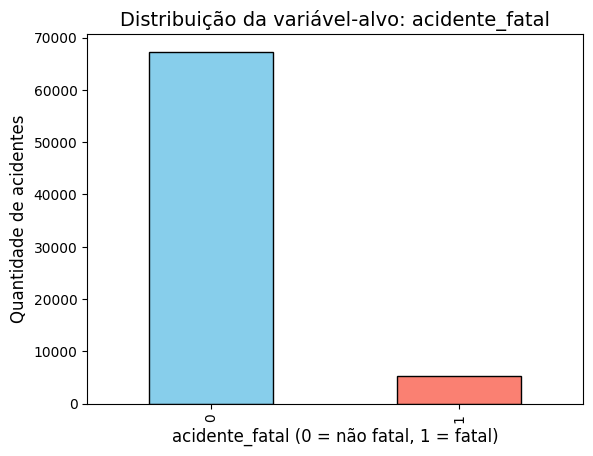

In [79]:
ax = df["acidente_fatal"].value_counts().sort_index().plot(
    
    kind="bar", 
    color=["skyblue", "salmon"], 
    edgecolor="black"
) 

# Personalização do gráfico 
ax.set_title("Distribuição da variável-alvo: acidente_fatal", fontsize=14)
ax.set_xlabel("acidente_fatal (0 = não fatal, 1 = fatal)", fontsize=12) 
ax.set_ylabel("Quantidade de acidentes", fontsize=12)

### 30. Gerar Base analítica completa 

### Objetivo 
    
    - Cópia da base tratada: preservar todos os tratamentos realizados até aqui.   
    
    - Variáveis descritivas: manter colunas originais e derivadas que ajudam na análise. 
    
    - Indicadores de gravidade: incluir métricas como total_vitimas, acidente_grave, indice_gravidade       
    
    - Uso futuro: essa base será utilizada nos módulos 5 e 6 (EDA e dashboards). 

In [80]:
# criar base analítica completa a partir da base tratada
base_analitica = df.copy()

In [81]:
# Conferir dimensões e colunas 
print("Base analítica completa: ")
print("Linhas e colunas: ", base_analitica.shape) 
print("\n Colunas disponíveis: ") 
print("base_analitica.columns.tolist()")

Base analítica completa: 
Linhas e colunas:  (72529, 44)

 Colunas disponíveis: 
base_analitica.columns.tolist()


### 31. Selecionar variáveis modeláveis 

### Objetivo

    - Variáveis de localidade: incluir uf, br_formatada, municipio  

    - Variáveis temporais: mes, trimestre, dia_semana, dia_semana_num, fim_de_semana,
      hora, faixa_horaria, turno, fase_dia

    - Variáveis explicativas: causa_acidente, tipo_acidente, condicao_metereologica, tipo_pista,
      tracado_via, uso_solo

    - Variável-alvo: acidente_fatal. 

In [82]:
# Lista de variáveis modeláveis
variaveis_modelaveis = [ 

    "uf", "br_formatada", "municipio", "mes", "trimestre", 
    "dia_semana", "dia_semana_num", "fim_de_semana", 
    "hora", "faixa_horaria", "turno", "fase_dia", 
    "causa_acidente", "tipo_acidente", "condicao_metereologica", 
    "tipo_pista", "tracado_via", "uso_solo", "acidente_fatal"
]

In [83]:
# Garantir que só entram colunas existentes 
variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns] 

In [84]:
# Criar base modelável 
base_modelavel = df[variaveis_modelaveis].copy()

In [85]:
# Conferir dimensões 
print("Base modelável criada: ") 
print("Linhas e colunas: ", base_modelavel.shape)
print("\n Colunas selecionadas: ") 
print(base_modelavel.columns.tolist())

Base modelável criada: 
Linhas e colunas:  (72529, 19)

 Colunas selecionadas: 
['uf', 'br_formatada', 'municipio', 'mes', 'trimestre', 'dia_semana', 'dia_semana_num', 'fim_de_semana', 'hora', 'faixa_horaria', 'turno', 'fase_dia', 'causa_acidente', 'tipo_acidente', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'acidente_fatal']


### 32. Verificar data leakage 

### Objetivo

    - Mortos fora da modelável: garantir que variáveis diretamente ligadas ao desfecho não estejam presentes. 
    
    - Feridos fora da modelável: excluir colunas que já carregam informação sobre o resultado 

    - Total_vitimas fora da modelável: evitar indicadores derivados que antecipam o alvo. 

    - Indice_gravidade fora da modelável: remover métricas que sintetizam o desfecho.

In [86]:
# Lista de variáveis proíbidas (potenciais data leakage) 
variaveis_proibidas = [
    
    "mortos", "feridos", "feridos_leves", "feridos_graves", 
    "total_vitimas", "indice_gravidade", "acidente_grave", 
    "classificacao_acidente"
]

In [87]:
# Função para verificar data leakage 
def verificar_data_leakage(base, proibidas): 
    
    presentes = [c for c in proibidas if c in base.columns] 
    if presentes: 
        
        raise ValueError(f"Data leakage detectado: {presentes}") 
        
    return "OK - nenhuma variável proibida encontrada."

# Executar verificação 
resultado = verificar_data_leakage(base_modelavel, variaveis_proibidas)
print(resultado)

OK - nenhuma variável proibida encontrada.


### 35. Tratamento final de nulos na base modelável 

### Objetivo

    - Categóricos como IGNORADO: preencher valores ausentes em variáveis categóricas com "IGNORADO"  
    
    - Númericas com -1: usar -1 como valor operacional quando necessário. 

    - Alvo preservado: não alterar a coluna acidente_fatal. 

    - Evitar erro: garantir que não haja nulos que atrapalhem algoritmos de modelagem. 

In [88]:
# Tratamento final de nulos na base modelável 
for coluna in base_modelavel.columns: 
    
    if coluna == "acidente_fatal": 
        
        continue # preservar alvo 
        
    if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string": 
        
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO") 
        
    else: 
        
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1) 
        
# Conferir se ainda restam nulos
print("Nulos remanescentes na base modelável (top 10 colunas): \n") 
print(base_modelavel.isna().sum().sort_values(ascending = False).head(10))

Nulos remanescentes na base modelável (top 10 colunas): 

uf                0
br_formatada      0
municipio         0
mes               0
trimestre         0
dia_semana        0
dia_semana_num    0
fim_de_semana     0
hora              0
faixa_horaria     0
dtype: int64


### 36. Exportar bases tratadas

In [89]:
# Exportar base analítica 
base_analitica.to_csv(
    
    ARQUIVO_BASE_ANALITICA,
    index = False,
    sep = SEPARADOR, 
    encoding = ENCODING_SAIDA
)

In [90]:
# Exportar base modelável 
base_modelavel.to_csv(

    ARQUIVO_BASE_MODELAVEL,
    index = False, 
    sep = SEPARADOR, 
    encoding = ENCODING_SAIDA
)

In [91]:
# Mensagem de confirmação 
print("Arquivos exportados com sucesso. ")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados com sucesso. 
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv


In [92]:
# Reabrir arquivos exportados para validação 
valid_analitica = pd.read_csv(
    
    ARQUIVO_BASE_ANALITICA, 
    sep = SEPARADOR, 
    encoding = ENCODING_SAIDA
)

In [93]:
valid_modelavel = pd.read_csv(
    
    ARQUIVO_BASE_MODELAVEL, 
    sep = SEPARADOR,
    encoding = ENCODING_SAIDA
)

In [94]:
# Conferir dimensões 
print("Bases reabertas para validação: ") 
print("Analítica: ", valid_analitica.shape)
print("Modelável: ", valid_modelavel.shape)

Bases reabertas para validação: 
Analítica:  (72529, 44)
Modelável:  (72529, 19)


In [95]:
# Garantir consistência com as bases originais 
assert len(valid_analitica) == len(base_analitica), "Divergência na base analítica" 
assert len(valid_modelavel) == len(base_modelavel), "Divergência na base modelável" 

In [96]:
print("Bases reabertas com sucesso e consistentes com os originais.")

Bases reabertas com sucesso e consistentes com os originais.


### 37. Reabrir arquivos exportados 

### Objetivo

    - Validação pós-exportação: confirmar que os arquivos foram salvos corretamente 
    
    - Conferir dimensões: verificar se número de linhas e colunas bate com a base original  

    - Garantir legibilidade: checar se os dedos podem ser lidos sem problemas 

    - Detectar erro de encoding: validar se acentução e caracteres especiais estão preservados. 

In [97]:
# Reabrir arquivos exportados para validação 
valid_analitica = pd.read_csv(

    
    ARQUIVO_BASE_ANALITICA,
    sep = SEPARADOR, 
    encoding = ENCODING_SAIDA 
)

valid_modelavel = pd.read_csv(
    
    ARQUIVO_BASE_MODELAVEL,
    sep = SEPARADOR, 
    encoding = ENCODING_SAIDA
)

# Conferir dimensões 
print("Base reabertas para validação: ") 
print("Analítica: ", valid_analitica.shape) 
print("Modelável: ", valid_modelavel.shape) 

# Garantir consistência com as bases originais 
assert len(valid_analitica) == len(base_analitica), "Divergência na base analítica"
assert len(valid_analitica) == len(base_modelavel), "Divergência na base modelável" 

print("Bases reabertas com sucesso e consistentes com as originais")

Base reabertas para validação: 
Analítica:  (72529, 44)
Modelável:  (72529, 19)
Bases reabertas com sucesso e consistentes com as originais


### 38. Gerar dicionário das variáveis criadas  

### Objetivo

    - Descrição das variáveis: registrar em texto claro que cada nova coluna significa
    
    - Uso previsto: indicar se a variável será usada como alvo, em análise ou em modelagem  

    - Apoio à avaliação: facilitar a interpretação dos resultados e auditoria do projeto 

    - Apoio aos módulos seguintes: servir como referência para EDA, dashboards e modelagem.  

In [98]:
# Criar dicionário das variáveis criadas 
linhas_dic = [ 

    {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso": "alvo"}, 
    {"variavel": "total_vitimas",  "descricao": "mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
    {"variavel": "indice_gravidade", "descricao": "mortos * 3 + feridos_graves * 2 + feridos_leves", "uso": "analise/dashboard"}, 
    {"variavel": "br_formatada", "descricao": "BR padronizada no formato BR - 000", "uso": "analise/modelagem"}, 
    {"variavel": "chave_localidade", "descricao": "UF + municipio + BR formatada", "uso": "analise/dashboard"}, 
]

# Converter em DataFrame 
dicionario = pd.DataFrame(linhas_dic) 

# Exportar para CSV
dicionario.to_csv(
    
    ARQUIVO_DICIONARIO, 
    index = False,
    sep = SEPARADOR, 
    encoding = ENCODING_SAIDA
)

# Exibir dicionário 
print("Dicionário das variáveis criadas: \n") 
display(dicionario)

Dicionário das variáveis criadas: 



,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos * 3 + feridos_graves * 2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR - 000,analise/modelagem
4,chave_localidade,UF + municipio + BR formatada,analise/dashboard


### 39. Registrar decisões de tratamento 

### Objetivo

     Data da geração: incluir a data e hora em que o arquivo foi criado.

     Regras adotadas: documentar padronizações e critérios aplicados.

     Arquivos gerados: listar os arquivos finais exportados.

     Justificativa metodológica: explicar por que cada decisão foi tomada. 

In [99]:
from datetime import datetime

# Texto de documentação das decisões
texto_decisoes = f"""
# Decisões de tratamento — Módulo 4

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

# Gravar arquivo de decisões
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")

# Confirmar criação
print("📑 Arquivo de decisões gerado em logs:")
print(ARQUIVO_DECISOES)


📑 Arquivo de decisões gerado em logs:
logs/decisoes_tratamento_modulo4.md


### 40. Criar README do projeto

Objetivo

    Objetivo do projeto: explicar em poucas linhas a finalidade da preparação dos dados.

    Variável-alvo: documentar a definição de acidente_fatal.

    Bases geradas: listar base_analitica e base_modelavel.

    Observação sobre data leakage: registrar que variáveis derivadas do desfecho foram excluídas da base mod.

In [100]:
# Criar README do projeto
readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de decisão explicável.

## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.

## Observação metodológica
A base modelável exclui mortos, feridos, total_vitimas, indice_gravidade e variáveis diretamente derivadas do desfecho.
"""

# Gravar README
ARQUIVO_README.write_text(readme, encoding="utf-8")

# Confirmar criação
print("📑 README criado com sucesso:", ARQUIVO_README)


📑 README criado com sucesso: README.md


### 41 — Resumo final da preparação

### Objetivo

    Dimensões das bases: confirmar número de linhas e colunas em cada base.

    Taxa global de fatalidade: calcular proporção de acidentes fatais em toda a base.

    Conferência final: validar consistência dos dados após exportação e reabertura.

    Evidência para avaliação: gerar relatório sintético para auditoria e apresentação.

In [101]:
# Resumo final da preparação
resumo_final = pd.DataFrame([
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "taxa_global_acidente_fatal", "valor": round(base_modelavel["acidente_fatal"].mean() * 100, 2)},
])

print("📊 Resumo final da preparação:\n")
display(resumo_final)


📊 Resumo final da preparação:



,item,valor
0,linhas_base_analitica,72529.00
1,colunas_base_analitica,44.00
2,linhas_base_modelavel,72529.00
3,colunas_base_modelavel,19.00
4,taxa_global_acidente_fatal,7.18


### 42. Verificação de erros comuns na leitura do CSV

In [102]:
### Verifica questões de colunas e linhas no csv
print("Dimensão da base: ", df.shape)
display(df.head())

Dimensão da base:  (72529, 44)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano,mes,trimestre,dia_semana_num,fim_de_semana,hora,turno,faixa_horaria,acidente_fatal,total_vitimas,acidente_grave,indice_gravidade,br_formatada,chave_localidade
0,652493,2025-01-01,QUARTA-FEIRA,06:20:00,SP,116,225.0,GUARULHOS,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,TOMBAMENTO,COM VÍTIMAS FERIDAS,PLENO DIA,DECRESCENTE,CÉU CLARO,MÚLTIPLA,RETA;DECLIVE,SIM,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP,2025,1,1,2,0,6,MANHA,06H-08H,0,1,0,1,BR-116,SP_BR-116
1,652519,2025-01-01,QUARTA-FEIRA,07:50:00,CE,116,NaN,PENAFORTE,PISTA ESBURACADA,COLISÃO FRONTAL,IGNORADO,PLENO DIA,CRESCENTE,CÉU CLARO,SIMPLES,RETA,NÃO,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE,2025,1,1,2,0,7,MANHA,06H-08H,1,2,1,4,BR-116,CE_BR-116
2,652522,2025-01-01,QUARTA-FEIRA,08:45:00,PR,369,NaN,CORNELIO PROCOPIO,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,COLISÃO TRASEIRA,COM VÍTIMAS FERIDAS,PLENO DIA,CRESCENTE,SOL,DUPLA,RETA;ACLIVE,SIM,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR,2025,1,1,2,0,8,MANHA,06H-08H,0,3,0,3,BR-369,PR_BR-369
3,652544,2025-01-01,QUARTA-FEIRA,11:00:00,PR,116,74.0,CAMPINA GRANDE DO SUL,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,SAÍDA DE LEITO CARROÇÁVEL,COM VÍTIMAS FERIDAS,PLENO DIA,CRESCENTE,CÉU CLARO,DUPLA,RETA,NÃO,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR,2025,1,1,2,0,11,MANHA,09H-11H,0,1,0,1,BR-116,PR_BR-116
4,652549,2025-01-01,QUARTA-FEIRA,09:30:00,MG,251,471.0,FRANCISCO SA,VELOCIDADE INCOMPATÍVEL,COLISÃO FRONTAL,COM VÍTIMAS FERIDAS,PLENO DIA,DECRESCENTE,CHUVA,SIMPLES,CURVA;DECLIVE,NÃO,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG,2025,1,1,2,0,9,MANHA,09H-11H,0,2,1,3,BR-251,MG_BR-251


### 43. Erros comuns no alvo 

### Regra do Acidente fatal 
    
    * Definição clara
    
      - acidente_fatal = 1 quando mortos >=1 
      - acidente_tatal = 0 quando mortos = 0 
      
    * Justificativa: 
     
      - O alvo é binário e reflete a gravidade máxima do acidente. 
      
      - Feridos não entram na definição, pois não caracterizam fatalidade
      
      - Nulos devem ser tratados para não comprometer a consistência. 

### 44. Erros comuns de data leakage 

In [103]:
# Variáveis proíbidas por risco de data leakage 
variaveis_proibidas = [
    
    "mortos", "feridos", "feridos_leves", "feridos_graves", 
    "total_vendas", "indice_gravidade", "classificacao_acidente"
]

In [105]:
# Atualizar dicionário com marcação de proíbidas 
dicionario["proibida"] = dicionario["variavel"].apply(
    
    lambda v: "SIM" if v in variaveis_proibidas else "NÃO"
)

In [106]:
# Exportar dicionário atualizado 
dicionario.to_csv(
    
    ARQUIVO_DICIONARIO,
    index = False, 
    sep = SEPARADOR,
    encoding = ENCODING_SAIDA
)

In [107]:
# Conferir resultado 
print("Dicionário atualizado com variáveis proíbidas: ") 
display(dicionario[dicionario["proibida"] == "SIM"])

Dicionário atualizado com variáveis proíbidas: 


,variavel,descricao,uso,proibida
2,indice_gravidade,mortos * 3 + feridos_graves * 2 + feridos_leves,analise/dashboard,SIM


### Checklist final da entrega

In [108]:
# Checklist final da entrega

print("✅ Notebook executado sem erro até aqui.")

# Conferir se bases foram exportadas
print("📂 Arquivos em dados_tratados:")
print("-", ARQUIVO_BASE_ANALITICA.exists(), ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL.exists(), ARQUIVO_BASE_MODELAVEL)

# Conferir se README foi criado
print("📑 README presente:", ARQUIVO_README.exists(), ARQUIVO_README)

# Conferir se decisões foram registradas
print("📝 Decisões registradas:", ARQUIVO_DECISOES.exists(), ARQUIVO_DECISOES)

# Conferir ausência de leakage (variáveis proibidas)
variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "classificacao_acidente"
]
proibidas_presentes = [v for v in variaveis_proibidas if v in base_modelavel.columns]

if proibidas_presentes:
    print("❌ Atenção: variáveis proibidas encontradas na base modelável:", proibidas_presentes)
else:
    print("✅ Leakage ausente: nenhuma variável proibida na base modelável.")


✅ Notebook executado sem erro até aqui.
📂 Arquivos em dados_tratados:
- True dados_tratados/base_analitica_prf_2025.csv
- True dados_tratados/base_modelavel_prf_2025.csv
📑 README presente: True README.md
📝 Decisões registradas: True logs/decisoes_tratamento_modulo4.md
✅ Leakage ausente: nenhuma variável proibida na base modelável.


# Etapa 52 — Critérios de qualidade

- ✅ Correção técnica: notebook executa sem erro
- ✅ Reprodutibilidade: kernel reiniciado e rodado do início ao fim
- ✅ Documentação: README, dicionário e decisões registradas
- ✅ Separação correta das bases: analítica e modelável exportadas em dados_tratados
- ✅ Prevenção de vazamento: variáveis proibidas ausentes da base modelável


### Etapa 53 — Conexão com Módulo 5

####  A base analítica será usada para:

- Alimentar a EDA (Análise Exploratória de Dados)
- Explorar indicadores
- Cruzar variáveis com `acidente_fatal`
- Registrar hipóteses para modelagem

#### Perguntas que a base analítica permite responder:

1. Quais BRs concentram maior proporção de acidentes fatais?
2. Qual a distribuição de acidentes fatais por tipo de causa?
3. Existe diferença na taxa de fatalidade entre estados (UF) ou regiões do país?


### Etapa 54.  Conexão com Módulo 7

- A base modelável alimentará a árvore de decisão.

- Confirmado: não há variáveis proibidas (sem data leakage).
    
- O foco da modelagem será em explicabilidade, permitindo interpretar como cada variável 
  influencia a probabilidade de acidente fatal.


### Etapa 56. Fechamento do Módulo 4


- ✅ Dados preparados com rigor
- ✅ Duas bases com finalidades distintas (analítica e modelável)
- ✅ Notebook reprodutível (executa do início ao fim sem erro)
- ✅ Documentação pronta para avaliação (README, dicionário, decisões)
- ✅ Pacote final submetido em `dados_tratados` + `logs`
